# **DATA MODELING AND MODEL EVALUATION**

---

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from scipy import stats

# Libraries machine learning
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

## **Load Data**

In [2]:
hotel_path = "../../data/processed/hotel_pricing_master_dataset.csv"
weather_path = "../../data/processed/weather_cleaned.csv"
hotel_data = pd.read_csv(hotel_path)
weather_data = pd.read_csv(weather_path)

## **Modeling Question**

### **1. The question**

> *Mô hình XGBoost và Random Forest khác nhau như thế nào về độ chính xác dự báo giá phòng trên bộ dữ liệu đa thị trường (Đà Nẵng, TP.HCM, Phú Quốc), và phân tích mức độ đóng góp của các biến đầu vào trong mô hình tốt nhất cho thấy vai trò tương đối của vị trí, tiện nghi và yếu tố mùa vụ tại từng thành phố ra sao?*

### **2. Motivation & Benefits**

#### **2.1. Why is this question worth investigating?**

Dự báo giá phòng khách sạn là một bài toán quen thuộc trong phân tích dữ liệu, tuy nhiên việc xây dựng một mô hình hoạt động ổn định trên nhiều thị trường khác nhau vẫn là thách thức lớn. Phần lớn các phân tích trước đây chỉ tập trung vào một địa điểm cụ thể hoặc sử dụng các mô hình đơn giản, chưa phản ánh đầy đủ sự khác biệt giữa đô thị lớn, thành phố du lịch và điểm đến nghỉ dưỡng. Trong khi đó, giá phòng chịu ảnh hưởng đồng thời của nhiều yếu tố như vị trí, tiện nghi, thời gian và điều kiện thị trường, với mức độ tác động thay đổi theo từng địa phương.

Việc so sánh hai mô hình phổ biến là Random Forest và XGBoost trên dữ liệu đa thị trường cho phép kiểm chứng liệu các mô hình học máy hiện đại có thực sự cải thiện độ chính xác dự báo trong bối cảnh dữ liệu phức tạp hay không. Đồng thời, câu hỏi này giúp đánh giá tính phù hợp của cách tiếp cận chung so với nhu cầu xây dựng mô hình thích ứng theo từng thị trường cụ thể.

#### **2.2. What benefits or insights would be answering this question provide?**

Kết quả nghiên cứu câu hỏi mang lại giá trị ở cả khía cạnh dự báo và phân tích. 

**Về dự báo**, việc xác định được mô hình có sai số thấp hơn giúp thiết lập một chuẩn tham chiếu đáng tin cậy cho các hệ thống định giá, hạn chế rủi ro đặt giá không phù hợp với nhu cầu thực tế. 

**Về phân tích**, việc xem xét mức độ đóng góp của các yếu tố đầu vào giúp làm rõ cách hình thành giá tại từng thị trường, từ đó nhận diện sự khác biệt giữa các địa điểm như vai trò nổi bật của vị trí ở Đà Nẵng hay của tiện nghi tại Phú Quốc. Những hiểu biết này khó có thể rút ra từ các mô hình truyền thống.

#### **2.3. Who would care about the answer?**

Kết quả nghiên cứu câu hỏi có ý nghĩa trực tiếp đối với nhiều nhóm trong ngành du lịch và khách sạn. Các nhà quản lý doanh thu có thêm công cụ để xây dựng chiến lược giá linh hoạt dựa trên dữ liệu. Nhà đầu tư bất động sản nghỉ dưỡng có cơ sở rõ ràng hơn để quyết định nên ưu tiên vị trí hay nâng cấp tiện ích tại từng thị trường. Đồng thời, các nền tảng đặt phòng trực tuyến có thể sử dụng kết quả này để cải thiện hệ thống gợi ý giá cho đối tác khách sạn.

#### **2.4. What real-world problem or decision does this inform?**

Câu hỏi cung cấp cơ sở định lượng cho việc chuyển từ cách định giá cố định sang định giá linh hoạt, phản ánh sát hơn biến động của thị trường. Bên cạnh đó, kết quả phân tích giúp các cơ sở lưu trú điều chỉnh chiến lược sản phẩm phù hợp với từng địa điểm, tập trung đầu tư vào những yếu tố mang lại giá trị cao nhất cho khách hàng thay vì dàn trải nguồn lực. Điều này góp phần nâng cao hiệu quả kinh doanh và tính cạnh tranh trong dài hạn.

### **3. Data analysis**

#### **A. Preprocessing**

#### **1. Written Explanation**

Để việc so sánh hiệu suất giữa hai mô hình **XGBoost** và **Random Forest** được công bằng và đáng tin cậy, nhóm xây dựng một quy trình chuẩn bị dữ liệu gồm các bước chính sau:

**1. Hợp nhất dữ liệu:** Dữ liệu giá phòng được kết hợp với dữ liệu thời tiết theo thành phố và ngày nhận phòng. Việc bổ sung thông tin về nhiệt độ và lượng mưa giúp mô hình phản ánh tốt hơn các yếu tố bên ngoài ảnh hưởng đến giá, đặc biệt quan trọng khi so sánh những thị trường có điều kiện khí hậu khác nhau như Đà Nẵng, TP.HCM và Phú Quốc.

**2. Xử lý giá trị thiếu:** Các giá trị thiếu được điền dựa trên đặc trưng riêng của từng thành phố, giúp giữ nguyên phân bố dữ liệu địa phương và tránh sai lệch khi so sánh giữa các thị trường.

**3. Xây dựng các biến đầu vào có ý nghĩa:** Giá phòng được chuyển sang thang log để giảm ảnh hưởng của các mức giá quá cao và giúp mô hình học tốt hơn trên toàn bộ dải giá. Ngoài ra, các biến kết hợp giữa vị trí, mùa vụ và mức độ tiện nghi được tạo ra nhằm mô tả đầy đủ hơn giá trị dịch vụ, thay vì chỉ dựa vào các biến đơn lẻ.

**4. Mã hóa biến phân loại một cách phù hợp:** Những biến có thứ tự tự nhiên như chất lượng thời tiết hoặc ngày trong tuần được mã hóa theo mức độ tăng dần, trong khi các biến không có thứ tự được chuyển sang dạng nhị phân. Riêng biến thành phố được giữ lại ở dạng gốc để phục vụ cho việc chia dữ liệu cân bằng và phân tích chi tiết kết quả theo từng thị trường ở các bước sau.

#### **2. Code Implementation**

- **Hợp nhất dữ liệu**

In [3]:
def merge_hotel_weather_data(hotel_data: pd.DataFrame, weather_data: pd.DataFrame) -> pd.DataFrame:
    
    hotel_data = hotel_data.copy()
    weather_data = weather_data.copy()
    hotel_data["check_in_date"] = pd.to_datetime(hotel_data["check_in_date"])
    weather_data["datetime"] = pd.to_datetime(weather_data["datetime"])

    city_mapping = {
        "Da Nang": "Da Nang",
        "Ho Chi Minh": "Ho Chi Minh City",
        "Phu Quoc": "Phu Quoc"
    }
    hotel_data["city_for_merge"] = hotel_data["City"].map(city_mapping)

    # Merge datasets
    merged_data = pd.merge(
        hotel_data,
        weather_data,
        left_on=["check_in_date", "city_for_merge"],
        right_on=["datetime", "city_name"],
        how="left"
    )
    print(f"Merged dataset shape: {merged_data.shape}")
    return merged_data

In [4]:
merged_data = merge_hotel_weather_data(hotel_data, weather_data)

Merged dataset shape: (27209, 336)


- **Xử lý giá trị thiếu**

In [5]:
def handle_missing_values(data: pd.DataFrame) -> pd.DataFrame:

    df = data.copy()

    initial_missing = df.isna().sum().sum()
    print(f"Initial missing values: {initial_missing:,}")

    missing_columns = df.columns[df.isna().any()].tolist()
    if "City" in df.columns and df["City"].isna().any():
        df["City"] = df["City"].fillna(df["City"].mode()[0])
        print("Missing values in 'City' column have been imputed using mode.")
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) > 0:
        df[numeric_cols] = df.groupby("City")[numeric_cols].transform(
            lambda x: x.fillna(x.median())
        )
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
                          
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    for col in categorical_cols:
        if df[col].isna().any():
            mode_value = df[col].mode()
            fill_value = mode_value.iloc[0] if not mode_value.empty else "Unknown"
            df[col] = df[col].fillna(fill_value)
    datetime_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64"]).columns

    for col in datetime_cols:
        if df[col].isna().any():
            df[col] = df[col].ffill().bfill()

    remaining_missing = df.isna().sum().sum()
    if remaining_missing > 0:
        remaining_cols = df.columns[df.isna().any()].tolist()
        print(f"Remaining missing values detected: {remaining_missing}")
        print(f"Affected columns: {remaining_cols}")
    else:
        print("Missing value handling completed successfully. No missing values remain.")
    return df

In [6]:
final_model_data = handle_missing_values(merged_data)

Initial missing values: 787,598
Missing value handling completed successfully. No missing values remain.


- **Xây dựng các biến đầu vào có ý nghĩa**

In [7]:
def build_features(df: pd.DataFrame, target: str = "Price_Display") -> pd.DataFrame:

    df_fe = df.copy()

    # Target transformation
    df_fe["log_price"] = np.log1p(df_fe[target])

    # Interaction features
    df_fe["Distance_x_Season"] = df_fe["Distance_Center"] * df_fe["Is_Peak_Season"]
    df_fe["Beach_x_Season"] = df_fe["Nearest_Beach_Dist"] * df_fe["Is_Peak_Season"]
    df_fe["Room_Quality_Index"] = df_fe["Review_Score"] * df_fe["Star_Rating"]
    df_fe["Amenity_Density"] = df_fe["Amenity_Count"] / (df_fe["room_size"] + 1)

    print(f"Dataset shape after feature creation: {df_fe.shape}")
    return df_fe

In [8]:
df_fe = build_features(final_model_data)

Dataset shape after feature creation: (27209, 341)


- **Mã hóa biến phân loại một cách phù hợp**

In [9]:
def prepare_model_features(df_fe: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, dict]:
    """
    Select modeling features and apply appropriate encoding strategies
    """

    # Feature groups
    features_dict = {
        "Room": [
            "room_size", "max_occupancy", "num_bedrooms", "Star_Rating",
            "Review_Score", "Review_Count", "Amenity_Count",
            "Amenity_Density", "Room_Quality_Index", "Has_Pool"
        ],
        "Location": [
            "Distance_Center", "Dist_airport_km", "Nearest_Beach_Dist",
            "Location_Quality_Score", "Distance_Center_Score"
        ],
        "Time_Season": [
            "Is_Peak_Season", "day_of_week", "Check_in_Month", "is_weekend"
        ],
        "Weather": ["temp", "precip", "humidity", "weather_quality"],
        "Promotion": ["Discount_Percent", "Free_Cancel", "Free_Breakfast"],
        "Interaction": ["Distance_x_Season", "Beach_x_Season"],
        "City": ["City"]
    }

    selected_features = [f for group in features_dict.values() for f in group]
    data_model = df_fe[selected_features + ["log_price"]].copy()

    # Ordinal encoding
    weather_map = {"Good": 3, "Fair": 2, "Poor": 1, "Bad": 0}
    data_model["weather_quality_encoded"] = (
        data_model["weather_quality"].map(weather_map).fillna(1)
    )
    data_model.drop("weather_quality", axis=1, inplace=True)

    day_map = {
        "Monday": 0, "Tuesday": 1, "Wednesday": 2,
        "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
    }
    data_model["day_encoded"] = data_model["day_of_week"].map(day_map).fillna(0)
    data_model.drop("day_of_week", axis=1, inplace=True)

    # One-hot encoding (exclude City for later split)
    X = pd.get_dummies(
        data_model.drop(["log_price", "City"], axis=1),
        drop_first=True
    )
    X["City_Original"] = data_model["City"]
    y = data_model["log_price"]

    print("Feature selection and encoding completed.")
    print(f"Final feature matrix shape: {X.shape}")
    print(f"Target variable shape: {y.shape}")

    return X, y, features_dict

In [10]:
X, y, feature_groups = prepare_model_features(df_fe)

Feature selection and encoding completed.
Final feature matrix shape: (27209, 29)
Target variable shape: (27209,)


#### **B. Analysis**

#### **1. Written Explanation**

Bài toán này sử dụng phương pháp phân tích định lượng kết hợp với các mô hình học máy nhằm dự báo giá phòng khách sạn và so sánh hiệu quả dự báo giữa các mô hình khác nhau. Bên cạnh đó, câu hỏi tập trung phân tích các yếu tố ảnh hưởng đến giá phòng tại nhiều thị trường du lịch, từ đó làm rõ sự khác biệt trong cơ chế định giá giữa các thành phố. 

Quy trình phân tích được triển khai theo các bước chính sau:

**1. Thiết lập Bài toán**

* **Loại bài toán:** Bài toán dự báo giá (hồi quy).
* **Mục tiêu nghiên cứu:** Ước lượng giá phòng khách sạn dựa trên các thông tin về chất lượng phòng, vị trí, thời gian và điều kiện thời tiết, đồng thời so sánh hiệu suất dự báo giữa hai mô hình Random Forest và XGBoost.
* **Bối cảnh dữ liệu:** Dữ liệu bao gồm nhiều thành phố với đặc điểm thị trường và mùa vụ khác nhau, dẫn đến sự chênh lệch đáng kể về mức giá. Ngoài ra, phân phối giá phòng không đồng đều, đòi hỏi các bước xử lý phù hợp để đảm bảo kết quả mô hình ổn định và đáng tin cậy.

**2. Chuẩn bị dữ liệu để huấn luyện và kiểm thử**

* **Phân chia dữ liệu:** Sau khi tiền xử lý, dữ liệu được chia thành tập huấn luyện (80%) và tập kiểm thử (20%). Việc phân chia được thực hiện theo từng thành phố nhằm đảm bảo mỗi thị trường đều được đại diện đầy đủ trong quá trình đánh giá mô hình.
* **Chuẩn hóa dữ liệu:** Các biến đầu vào được đưa về cùng thang đo bằng phương pháp chuẩn hóa phù hợp với dữ liệu có giá trị ngoại lai, giúp mô hình học hiệu quả hơn và hạn chế ảnh hưởng của các giá trị bất thường.

**3. Lựa chọn và Tối ưu Mô hình**

Bài làm lựa chọn hai mô hình học máy tiêu biểu để so sánh:

* **Random Forest:** Mô hình kết hợp nhiều cây quyết định nhằm tăng tính ổn định và giảm sai lệch trong dự báo.
* **XGBoost:** Mô hình học tăng cường, có khả năng cải thiện dần độ chính xác thông qua việc học từ các sai số trước đó.

Các tham số của mô hình được điều chỉnh thông qua quá trình tìm kiếm ngẫu nhiên kết hợp với kiểm tra chéo, nhằm giảm sai số dự báo và đảm bảo tính công bằng khi so sánh hiệu suất giữa hai mô hình.

**4. Đánh giá và So sánh Hiệu suất**

* Hiệu suất dự báo được đánh giá trên tập kiểm thử độc lập bằng các chỉ số phổ biến như sai số bình phương trung bình, sai số tuyệt đối trung bình và mức độ giải thích biến động giá.
* Ngoài việc so sánh trực tiếp các chỉ số, bài làm sử dụng kiểm định thống kê để xác định liệu sự khác biệt về hiệu suất giữa hai mô hình có thực sự đáng kể hay chỉ xuất phát từ biến động ngẫu nhiên trong dữ liệu.

**5. Phân tích Vai trò của Các Yếu tố Ảnh hưởng đến Giá**

* Mô hình có hiệu suất tốt nhất được huấn luyện riêng cho từng thành phố nhằm phản ánh đặc thù của từng thị trường.
* Các yếu tố đầu vào được nhóm thành các khía cạnh chính như chất lượng phòng, vị trí, tiện nghi và đánh giá, mùa vụ, thời tiết và các chương trình khuyến mãi.
* Việc so sánh mức độ đóng góp của các nhóm yếu tố giúp làm rõ sự khác biệt trong cơ chế định giá giữa các thành phố, từ đó rút ra các kết luận có giá trị thực tiễn cho hoạt động kinh doanh và quản lý giá phòng.

#### **2. Code Implementation**

**Chuẩn bị dữ liệu Train và Test** 

In [11]:
def prepare_train_test_data(
    X_processed: pd.DataFrame,
    y: pd.Series,
    city_col: str = "City_Original",
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Split data into training and testing sets using stratification by city
    """

    # Separate features and stratification variable
    X = X_processed.drop(city_col, axis=1)
    cities = X_processed[city_col]

    # Stratified train-test split
    X_train, X_test, y_train, y_test, cities_train, cities_test = train_test_split(
        X, y,
        cities,
        test_size=test_size,
        stratify=cities,
        random_state=random_state
    )

    print("Train-test split completed.")
    print(f"Training samples: {X_train.shape[0]:,}")
    print(f"Testing samples:  {X_test.shape[0]:,}")
    print("City distribution in test set:")
    print(cities_test.value_counts(normalize=True).round(3))

    # Robust scaling
    scaler = RobustScaler()

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    print("Feature scaling completed using RobustScaler.")
    return X_train_scaled, X_test_scaled, y_train, y_test, cities_train, cities_test, scaler

**Lựa chọn và tối ưu mô hình**

In [12]:
def evaluate_regression_metrics(y_true, y_pred, model_name: str) -> dict:
    return {
        "Model": model_name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

*Random Forest: Training and Hyperparameter Tuning*

In [13]:
def train_random_forest(X_train: np.ndarray, y_train: np.ndarray, random_state: int = 42) -> RandomForestRegressor:

    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [10, 15, 20, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", 0.5]
    }

    search = RandomizedSearchCV(
        estimator=RandomForestRegressor(random_state=random_state, n_jobs=-1),
        param_distributions=param_grid,
        n_iter=20,
        cv=3,
        scoring="neg_root_mean_squared_error",
        random_state=random_state,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    print("Random Forest training completed.")
    print(f"Best hyperparameters: {search.best_params_}")
    return search.best_estimator_

*XGBoost: Training and Hyperparameter Tuning*

In [14]:
def train_xgboost(X_train: np.ndarray, y_train: np.ndarray, random_state: int = 42) -> xgb.XGBRegressor:
    
    param_grid = {
        "n_estimators": [200, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [5, 7, 9],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9],
        "gamma": [0, 0.1]
    }

    search = RandomizedSearchCV(
        estimator=xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=random_state,
            n_jobs=-1
        ),
        param_distributions=param_grid,
        n_iter=30,
        cv=3,
        scoring="neg_root_mean_squared_error",
        random_state=random_state,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    print("XGBoost training completed.")
    print(f"Best hyperparameters: {search.best_params_}")
    return search.best_estimator_

#### **C. Results & Interpretation**

#### **1. Answer the question with evidence**

In [15]:
X_train, X_test, y_train, y_test, cities_train, cities_test, scaler = prepare_train_test_data(X_processed=X, y=y)

Train-test split completed.
Training samples: 21,767
Testing samples:  5,442
City distribution in test set:
City_Original
Da Nang             0.373
Ho Chi Minh City    0.370
Phu Quoc Island     0.257
Name: proportion, dtype: float64
Feature scaling completed using RobustScaler.


*Lựa chọn và tối ưu mô hình*

In [16]:
best_rf = train_random_forest(X_train, y_train)
best_xgb = train_xgboost(X_train, y_train)

Random Forest training completed.
Best hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
XGBoost training completed.
Best hyperparameters: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}


**Đánh giá và So sánh Hiệu suất**

*Quantitative Evaluation on the Independent Test Set*

In [17]:
def evaluate_on_test_set(model, X_test: np.ndarray, y_test: np.ndarray, model_name: str) -> dict:
    y_pred = model.predict(X_test)
    return evaluate_regression_metrics(y_test, y_pred, model_name), y_pred


# Generate predictions and metrics
rf_metrics, rf_pred_log = evaluate_on_test_set(
    best_rf, X_test, y_test, "Random Forest"
)
xgb_metrics, xgb_pred_log = evaluate_on_test_set(
    best_xgb, X_test, y_test, "XGBoost"
)

# Compare performance
comparison_df = pd.DataFrame([rf_metrics, xgb_metrics]).set_index("Model")
print("Test set performance (log scale):")
print(comparison_df)

Test set performance (log scale):
                   RMSE       MAE        R2
Model                                      
Random Forest  0.013361  0.001518  0.999756
XGBoost        0.008122  0.001289  0.999910


*Evaluation on the Original Price Scale*

In [18]:
# Convert predictions back to original scale
y_test_real = np.expm1(y_test)
rf_pred_real = np.expm1(rf_pred_log)
xgb_pred_real = np.expm1(xgb_pred_log)

# Compute RMSE in original scale
rf_rmse_real = np.sqrt(mean_squared_error(y_test_real, rf_pred_real))
xgb_rmse_real = np.sqrt(mean_squared_error(y_test_real, xgb_pred_real))

print("\nTest set performance (original price scale):")
print(f"Random Forest RMSE: {rf_rmse_real:,.0f}")
print(f"XGBoost RMSE:       {xgb_rmse_real:,.0f}")


Test set performance (original price scale):
Random Forest RMSE: 58,900
XGBoost RMSE:       27,467


*Statistical Significance Testing of Performance Differences*

In [19]:
# Compute absolute errors
rf_errors = np.abs(y_test_real - rf_pred_real)
xgb_errors = np.abs(y_test_real - xgb_pred_real)

# Wilcoxon signed-rank test
statistic, p_value = stats.wilcoxon(rf_errors, xgb_errors)

print("\nWilcoxon signed-rank test results:")
print(f"P-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    better_model = (
        "XGBoost" if xgb_errors.mean() < rf_errors.mean() else "Random Forest"
    )
    print(
        "Conclusion: The performance difference is statistically significant. "
        f"{better_model} demonstrates superior predictive accuracy."
    )
else:
    print(
        "Conclusion: No statistically significant difference is detected "
        "between the two models."
    )


Wilcoxon signed-rank test results:
P-value: 0.00000
Conclusion: The performance difference is statistically significant. XGBoost demonstrates superior predictive accuracy.


**Kết quả thực nghiệm và đánh giá hiệu năng mô hình**

Thử nghiệm được thực hiện trên tập dữ liệu gồm 27.209 quan sát, được chia thành tập huấn luyện và tập kiểm thử theo tỷ lệ 80:20. Việc phân chia sử dụng kỹ thuật phân tầng nhằm đảm bảo mỗi thị trường được đại diện hợp lý trong tập kiểm thử, bao gồm Đà Nẵng (khoảng 37,3%), TP.HCM (37,0%) và Phú Quốc (25,7%). Hai mô hình Random Forest và XGBoost được huấn luyện và tinh chỉnh tham số bằng cùng một quy trình nhằm đảm bảo tính công bằng trong so sánh.

Kết quả đánh giá trên tập kiểm thử cho thấy mô hình XGBoost đạt độ chính xác dự báo cao hơn rõ rệt so với Random Forest. Trên thang đo logarit của giá phòng, XGBoost có sai số dự báo thấp hơn và khả năng giải thích biến động dữ liệu gần như hoàn toàn. Khi chuyển kết quả về đơn vị tiền tệ thực tế, sự khác biệt càng thể hiện rõ: sai số dự báo trung bình của XGBoost thấp hơn khoảng một nửa so với Random Forest. Điều này cho thấy XGBoost có khả năng mô hình hóa tốt hơn các mối quan hệ phức tạp và không tuyến tính trong dữ liệu giá phòng.

Để kiểm tra xem sự khác biệt hiệu năng giữa XGBoost và Random Forest có mang ý nghĩa thống kê hay không, nhóm sử dụng kiểm định Wilcoxon signed-rank thay vì t-test vì đặc điểm của dữ liệu dự báo giá phòng. Sai số dự báo không tuân theo phân phối chuẩn và chứa nhiều giá trị lệch lớn do các phòng giá cao, khiến t-test kém phù hợp. 

Wilcoxon không yêu cầu giả định phân phối chuẩn và ít bị ảnh hưởng bởi các giá trị ngoại lai vì dựa trên thứ hạng thay vì giá trị trung bình (trái ngược với t-test dựa trên giá trị trung bình nên nhạy cảm với các trường hợp sai lệch lớn). Đồng thời, kiểm định này phù hợp với thiết kế dữ liệu bắt cặp, khi cả hai mô hình được đánh giá trên cùng một tập kiểm thử.

Do đó, Wilcoxon đảm bảo kết luận về sự khác biệt hiệu năng giữa hai mô hình là đáng tin cậy và phù hợp với dữ liệu thực tế.4

Kết quả kiểm định cho thấy xác suất xảy ra sự khác biệt do ngẫu nhiên là rất thấp, từ đó khẳng định hiệu suất vượt trội của XGBoost là có ý nghĩa thống kê.

Từ các kết quả thực nghiệm và kiểm định, bài làm kết luận rằng XGBoost là lựa chọn phù hợp hơn cho bài toán dự báo giá phòng trong bối cảnh dữ liệu đa thị trường. Độ chính xác cao và khả năng tổng quát hóa tốt của mô hình giúp giảm đáng kể sai lệch dự báo, qua đó mang lại giá trị thực tiễn cho các ứng dụng hỗ trợ định giá và ra quyết định trong ngành du lịch – khách sạn.

**Phân tích Vai trò của Các Yếu tố Ảnh hưởng đến Giá**

*Feature Categorization Logic*

In [20]:
def map_feature_to_category(feature_name: str) -> str:
    feature = feature_name.lower()
    if any(k in feature for k in ["size", "bed", "occupancy", "room", "quality"]):
        return "Room Quality"
    if any(k in feature for k in ["pool", "amenity", "star", "review"]):
        return "Amenities & Ratings"
    if any(k in feature for k in ["season", "month", "week", "weekend", "time"]):
        return "Seasonality"
    if any(k in feature for k in ["distance", "center", "beach", "location", "airport"]):
        return "Location"
    if any(k in feature for k in ["weather", "temp", "rain", "humid"]):
        return "Weather"
    if any(k in feature for k in ["discount", "promo", "free"]):
        return "Promotion"
    if "interaction" in feature:
        return "Interaction Effects"
    return "Other"

*City-specific Model Training and Feature Importance Extraction*

In [21]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

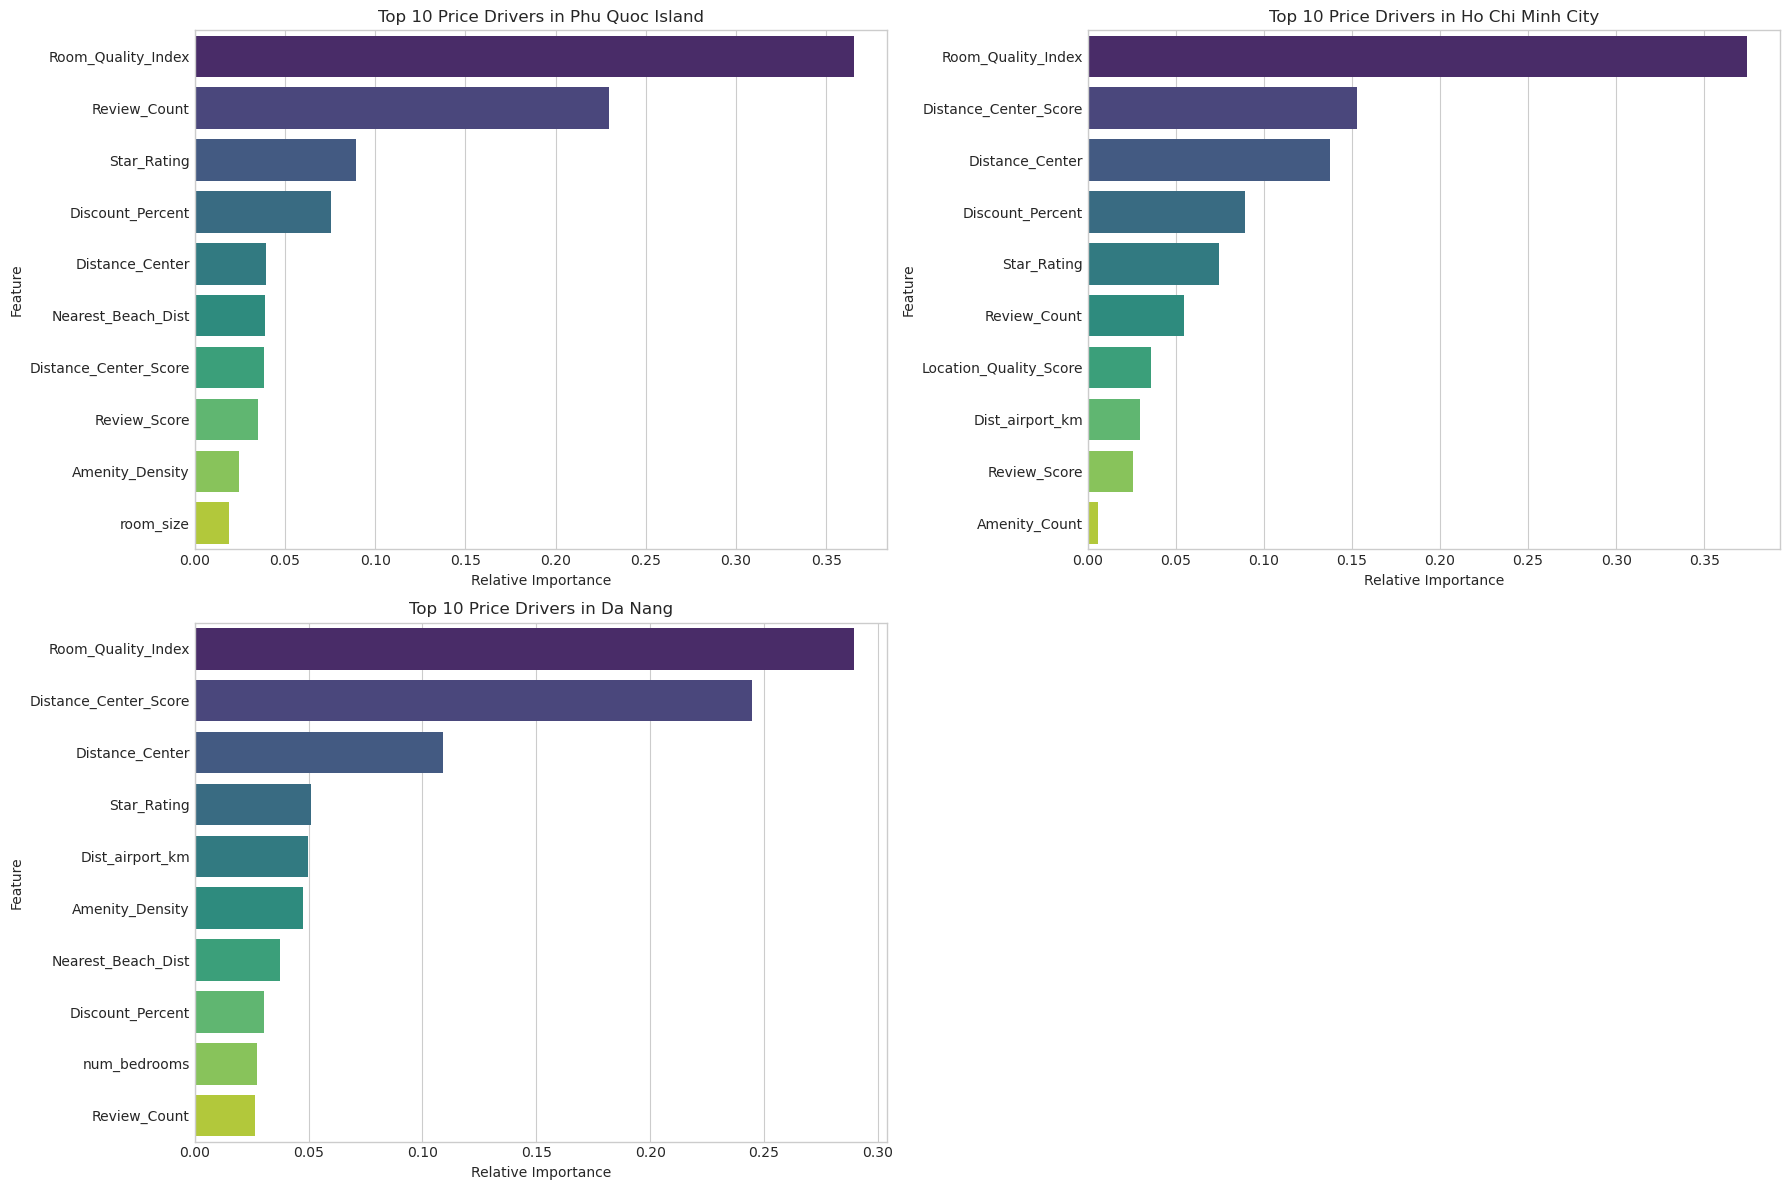

In [22]:
city_category_importance = {}

feature_columns = X_train.columns
analysis_model = best_xgb  # reuse tuned model safely

unique_cities = cities_train.unique()

plt.figure(figsize=(18, 12))

for idx, city in enumerate(unique_cities, start=1):
    city_mask = cities_train == city
    X_city = X_train.loc[city_mask]
    y_city = y_train.loc[city_mask]

    analysis_model.fit(X_city, y_city)

    importance_df = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": analysis_model.feature_importances_
    })

    importance_df["Category"] = importance_df["Feature"].apply(map_feature_to_category)

    category_importance = (
        importance_df
        .groupby("Category")["Importance"]
        .sum()
        .sort_values(ascending=False)
    )

    city_category_importance[city] = category_importance

    top_features = importance_df.sort_values(
        "Importance", ascending=False
    ).head(10)

    plt.subplot(2, 2, idx)
    sns.barplot(data=top_features, x="Importance", y="Feature", palette='viridis', hue = 'Feature', legend=False)
    plt.title(f"Top 10 Price Drivers in {city}")
    plt.xlabel("Relative Importance")
    plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [23]:
category_comparison_df = pd.DataFrame(city_category_importance).fillna(0)

print("Relative contribution of feature categories by city (percentage):")
print((category_comparison_df * 100).round(2))

Relative contribution of feature categories by city (percentage):
                     Phu Quoc Island  Ho Chi Minh City    Da Nang
Category                                                         
Amenities & Ratings            38.25         16.490000  15.230000
Location                       12.83         32.009998  44.099998
Other                           0.00          0.000000   0.000000
Promotion                       7.57          8.930000   3.050000
Room Quality                   41.32         42.560001  37.169998
Seasonality                     0.03          0.000000   0.440000
Weather                         0.00          0.000000   0.010000


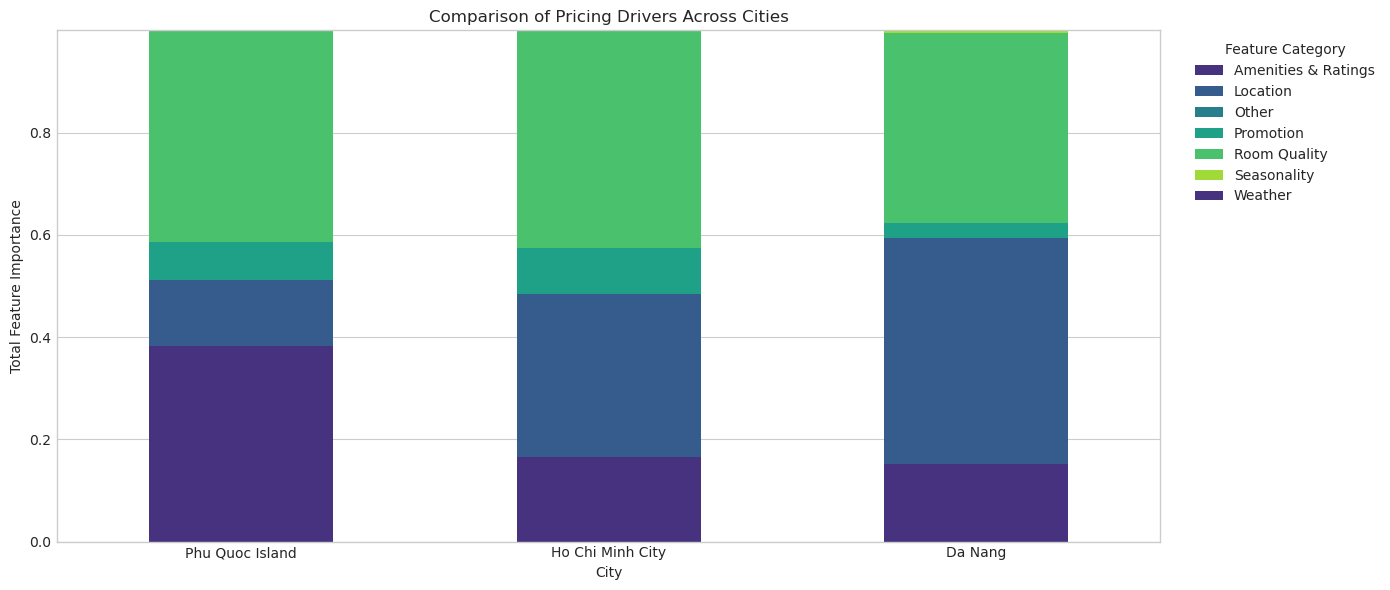

In [24]:
category_comparison_df.T.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)
plt.title("Comparison of Pricing Drivers Across Cities")
plt.ylabel("Total Feature Importance")
plt.xlabel("City")
plt.xticks(rotation=0)
plt.legend(title="Feature Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Dựa trên phân tích mức độ đóng góp của các nhóm đặc trưng trong mô hình XGBoost được huấn luyện riêng cho từng thành phố, kết quả cho thấy cơ chế hình thành giá phòng có sự khác biệt rõ rệt giữa các thị trường du lịch, phản ánh hành vi chi trả không đồng nhất của khách hàng.

Trước hết, **chất lượng phòng** đóng vai trò nền tảng tại tất cả các thị trường. Các yếu tố như hạng sao, diện tích phòng và chỉ số chất lượng tổng hợp đóng góp ổn định khoảng 37 – 43% vào khả năng dự báo của mô hình. Điều này cho thấy, bất kể vị trí địa lý, chất lượng cơ sở lưu trú vẫn là yếu tố cốt lõi định hình mức giá cơ bản.

Tuy nhiên, sự khác biệt lớn nhất nằm ở cách các thị trường đánh đổi giữa *vị trí* và *trải nghiệm dịch vụ*. Tại **Đà Nẵng**, giá phòng chịu ảnh hưởng mạnh từ yếu tố vị trí, với tỷ trọng cao nhất trong ba thành phố. Điều này phản ánh đặc thù của một đô thị biển, nơi khoảng cách đến các điểm du lịch chính có vai trò quyết định trong định giá. Ngược lại, tại **Phú Quốc**, tác động của vị trí giảm rõ rệt, trong khi các yếu tố liên quan đến tiện nghi và đánh giá của khách hàng lại trở nên nổi bật. Kết quả này cho thấy du khách tại thị trường nghỉ dưỡng đảo sẵn sàng trả giá cao hơn cho chất lượng trải nghiệm bên trong khu nghỉ dưỡng thay vì vị trí địa lý cụ thể. Trong khi đó, **TP.HCM** thể hiện cấu trúc cân bằng hơn giữa chất lượng phòng và vị trí, phù hợp với đặc điểm của một thị trường đô thị và công vụ.

Cuối cùng, các yếu tố *khuyến mãi* có ảnh hưởng ở mức vừa phải tại TP.HCM và Phú Quốc, nhưng ít tác động tại Đà Nẵng. Ngược lại, các biến liên quan đến *mùa vụ và thời tiết* đóng góp rất nhỏ vào mô hình. Điều này gợi ý rằng biến động theo mùa có thể đã được phản ánh gián tiếp thông qua chính sách giá và khuyến mãi, hoặc thị trường có xu hướng giữ mặt bằng giá tương đối ổn định trước các thay đổi ngắn hạn của thời tiết.

Tổng hợp các kết quả cho thấy, cách tiếp cận định giá đồng nhất cho mọi thị trường là chưa phù hợp. Thay vào đó, chiến lược tối ưu cần được điều chỉnh theo từng địa phương: tập trung khai thác lợi thế vị trí tại Đà Nẵng và TP.HCM, trong khi ưu tiên nâng cao chất lượng dịch vụ và trải nghiệm tại thị trường Phú Quốc.

**Kết luận chính.**

Kết quả thực nghiệm trên tập dữ liệu đa thị trường cho thấy mô hình XGBoost vượt trội rõ rệt so với Random Forest về độ chính xác dự báo. Sai số dự báo thực tế của XGBoost thấp hơn gần một nửa, và sự khác biệt này được xác nhận là có ý nghĩa thống kê thông qua kiểm định Wilcoxon. Nhờ khả năng dự báo ổn định hơn, mô hình XGBoost cung cấp nền tảng tin cậy để phân tích sâu cơ chế hình thành giá phòng giữa các thị trường.

Phân tích mức độ đóng góp của các yếu tố đầu vào cho thấy cấu trúc định giá không đồng nhất giữa các thành phố. Chất lượng phòng luôn giữ vai trò nền tảng trong việc xác định mặt bằng giá. Tuy nhiên, các yếu tố gia tăng giá trị lại khác nhau rõ rệt: tại Đà Nẵng, giá phòng phụ thuộc mạnh vào vị trí, trong khi tại Phú Quốc, tiện nghi và trải nghiệm lưu trú có ảnh hưởng lớn hơn, phản ánh đặc trưng của du lịch nghỉ dưỡng khép kín. Đáng chú ý, yếu tố mùa vụ có tác động hạn chế trong mô hình giá niêm yết, cho thấy biến động nhu cầu nhiều khả năng được phản ánh thông qua tỷ lệ lấp đầy hoặc các chính sách khuyến mãi thay vì điều chỉnh giá cơ sở.

Từ các kết quả này, bài làm đề xuất rằng chiến lược định giá và tối ưu doanh thu cần được điều chỉnh theo từng thị trường. Các đô thị du lịch như Đà Nẵng và TP.HCM nên tập trung khai thác lợi thế vị trí, trong khi các điểm đến nghỉ dưỡng như Phú Quốc cần ưu tiên nâng cao chất lượng tiện ích và trải nghiệm dịch vụ để gia tăng giá trị cảm nhận của khách hàng.

#### **2. Practical Meaning & Implications**

Kết quả phân tích câu hỏi không chỉ nhằm so sánh hiệu năng mô hình, mà còn cung cấp cơ sở định lượng cho các quyết định quản trị trong ngành khách sạn. Các phát hiện từ mô hình XGBoost cho thấy tiềm năng ứng dụng rõ rệt ở ba khía cạnh thực tiễn chính.

**Thứ nhất, nâng cao hệ thống định giá dựa trên dữ liệu.**

Việc XGBoost cho độ chính xác dự báo cao hơn đáng kể cho thấy định giá phòng có thể chuyển từ cách tiếp cận dựa trên quy tắc cố định sang dựa trên dữ liệu. Với sai số dự báo thấp hơn, mô hình giúp giảm rủi ro định giá không phù hợp, qua đó hỗ trợ các nền tảng đặt phòng và chuỗi khách sạn đưa ra mức giá linh hoạt và sát với nhu cầu thị trường hơn.

**Thứ hai, định hướng chiến lược đầu tư theo từng thị trường.**

Phân tích cho thấy không tồn tại một công thức đầu tư chung cho mọi địa điểm. Tại các đô thị du lịch như Đà Nẵng, giá trị phòng chịu ảnh hưởng mạnh từ vị trí, do đó ưu tiên quỹ đất thuận tiện di chuyển mang lại hiệu quả cao hơn. Ngược lại, tại các điểm đến nghỉ dưỡng như Phú Quốc, trải nghiệm lưu trú và hệ thống tiện ích đóng vai trò quyết định, gợi ý rằng đầu tư vào dịch vụ và không gian nghỉ dưỡng sẽ tạo lợi thế cạnh tranh bền vững hơn.

**Thứ ba, hỗ trợ xây dựng thông điệp tiếp thị phù hợp.**

Việc xác định rõ các yếu tố tác động đến giá giúp hoạt động tiếp thị tập trung đúng trọng tâm. Khách sạn tại TP.HCM và Đà Nẵng nên nhấn mạnh yếu tố vị trí và sự thuận tiện, trong khi các khu nghỉ dưỡng tại Phú Quốc cần làm nổi bật chất lượng tiện nghi và trải nghiệm. Đồng thời, kết quả cũng cho thấy chất lượng phòng luôn là yếu tố nền tảng ở mọi thị trường, nhấn mạnh vai trò không thể thay thế của các tiêu chuẩn dịch vụ cơ bản.

**Cuối cùng, mở ra cơ hội cải thiện chiến lược theo mùa.**

Việc yếu tố mùa vụ có ảnh hưởng hạn chế trong mô hình định giá gợi ý rằng giá niêm yết hiện tại còn ít phản ứng với biến động nhu cầu. Điều này tạo cơ hội cho các nhà quản lý áp dụng chiến lược điều chỉnh giá linh hoạt hơn trong giai đoạn cao điểm nhằm tối ưu hóa doanh thu, thay vì chỉ dựa vào việc tăng tỷ lệ lấp đầy.

#### **3. Surprises & Limitations**

**Surprises**

Kết quả phân tích cho thấy một số yếu tố vốn được xem là quan trọng lại có tác động rất hạn chế trong mô hình định giá. Cụ thể, các biến về mùa vụ và thời tiết gần như không ảnh hưởng đến giá niêm yết, ngay cả tại những thị trường có tính mùa vụ cao như Đà Nẵng. Điều này gợi ý rằng nhiều khách sạn tại Việt Nam vẫn duy trì mức giá tương đối cố định trong năm và điều chỉnh doanh thu chủ yếu thông qua tỷ lệ lấp đầy, thay vì thay đổi giá linh hoạt theo điều kiện ngắn hạn. Bên cạnh đó, tại Phú Quốc, vị trí địa lý không còn là yếu tố chi phối giá mạnh nhất; thay vào đó, tiện nghi và trải nghiệm tổng thể đóng vai trò quyết định. Kết quả này phản ánh mô hình khu nghỉ dưỡng khép kín, nơi bản thân khách sạn trở thành điểm đến chính, làm giảm tầm quan trọng của khoảng cách đến trung tâm hay hạ tầng xung quanh.

**Limitations**

Mặc dù mô hình đạt độ chính xác cao, bài làm vẫn tồn tại một số giới hạn cần lưu ý. 

Thứ nhất, mô hình chưa tích hợp thông tin về giá của các đối thủ cạnh tranh, trong khi đây là yếu tố có ảnh hưởng trực tiếp đến quyết định định giá trong thực tế. 

Thứ hai, dữ liệu được thu thập tại một thời điểm nhất định nên phản ánh tốt sự khác biệt giá giữa các khách sạn, nhưng chưa đủ để phân tích xu hướng biến động giá dài hạn theo thời gian. 

Cuối cùng, bài làm sử dụng giá niêm yết trên các nền tảng OTA, trong khi giá giao dịch thực tế có thể thấp hơn do khuyến mãi hoặc chính sách khách hàng thân thiết, dẫn đến sai lệch nhất định khi áp dụng kết quả cho dự báo doanh thu thực tế.